Rusty Bargain used car sales service is developing an app to attract new customers. In that app, you can quickly find out the market value of your car. You have access to historical data: technical specifications, trim versions, and prices. You need to build the model to determine the value. 

Rusty Bargain is interested in:

- the quality of the prediction;
- the speed of the prediction;
- the time required for training

## Data preparation

In [1]:
# import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import time
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from catboost import CatBoostRegressor

In [2]:
# load dataframe and display it
df = pd.read_csv('/datasets/car_data.csv')
display(df.head())

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Mileage,RegistrationMonth,FuelType,Brand,NotRepaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,24/03/2016 11:52,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,24/03/2016 00:00,0,70435,07/04/2016 03:16
1,24/03/2016 10:58,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,24/03/2016 00:00,0,66954,07/04/2016 01:46
2,14/03/2016 12:52,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,14/03/2016 00:00,0,90480,05/04/2016 12:47
3,17/03/2016 16:54,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,17/03/2016 00:00,0,91074,17/03/2016 17:40
4,31/03/2016 17:25,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,31/03/2016 00:00,0,60437,06/04/2016 10:17


In [3]:
# dataframe summary
df.describe()

,Price,RegistrationYear,Power,Mileage,RegistrationMonth,NumberOfPictures,PostalCode
count,354369.000000,354369.000000,354369.000000,354369.000000,354369.000000,354369.0,354369.000000
mean,4416.656776,2004.234448,110.094337,128211.172535,5.714645,0.0,50508.689087
std,4514.158514,90.227958,189.850405,37905.341530,3.726421,0.0,25783.096248
min,0.000000,1000.000000,0.000000,5000.000000,0.000000,0.0,1067.000000
25%,1050.000000,1999.000000,69.000000,125000.000000,3.000000,0.0,30165.000000
50%,2700.000000,2003.000000,105.000000,150000.000000,6.000000,0.0,49413.000000
75%,6400.000000,2008.000000,143.000000,150000.000000,9.000000,0.0,71083.000000
max,20000.000000,9999.000000,20000.000000,150000.000000,12.000000,0.0,99998.000000


In [4]:
# find missing values
print(df.isna().sum())
print("break")
print((df.isna().sum() / len(df) * 100).round(2))

DateCrawled              0
Price                    0
VehicleType          37490
RegistrationYear         0
Gearbox              19833
Power                    0
Model                19705
Mileage                  0
RegistrationMonth        0
FuelType             32895
Brand                    0
NotRepaired          71154
DateCreated              0
NumberOfPictures         0
PostalCode               0
LastSeen                 0
dtype: int64
break
DateCrawled           0.00
Price                 0.00
VehicleType          10.58
RegistrationYear      0.00
Gearbox               5.60
Power                 0.00
Model                 5.56
Mileage               0.00
RegistrationMonth     0.00
FuelType              9.28
Brand                 0.00
NotRepaired          20.08
DateCreated           0.00
NumberOfPictures      0.00
PostalCode            0.00
LastSeen              0.00
dtype: float64


In [5]:
# find types of missing values
# vehicletype
print('VehicleType')
print(df['VehicleType'].value_counts())
#gearbox
print('Gearbox')
print(df['Gearbox'].value_counts())
#model
print('Model')
print(df['Model'].value_counts())
#fueltype
print('FuleType')
print(df['FuelType'].value_counts())
#notrepaired
print('NotRepaired')
print(df['NotRepaired'].value_counts())

VehicleType
sedan          91457
small          79831
wagon          65166
bus            28775
convertible    20203
coupe          16163
suv            11996
other           3288
Name: VehicleType, dtype: int64
Gearbox
manual    268251
auto       66285
Name: Gearbox, dtype: int64
Model
golf                  29232
other                 24421
3er                   19761
polo                  13066
corsa                 12570
                      ...  
i3                        8
serie_3                   4
rangerover                4
serie_1                   2
range_rover_evoque        2
Name: Model, Length: 250, dtype: int64
FuleType
petrol      216352
gasoline     98720
lpg           5310
cng            565
hybrid         233
other          204
electric        90
Name: FuelType, dtype: int64
NotRepaired
no     247161
yes     36054
Name: NotRepaired, dtype: int64


In [6]:
# gas and petrol are the same thing?
df['FuelType'] = df['FuelType'].replace('gasoline', 'petrol')
# find percentage of missing values
print("Missing values percentage:")
print("FuelType:", (df['FuelType'].isna().sum() / len(df)) * 100, "%")
print("VehicleType:", (df['VehicleType'].isna().sum() / len(df)) * 100, "%")
#row count
print("Rows before:", len(df))
# drop the under ~10% rows
df = df.dropna(subset=['FuelType', 'VehicleType'])
print("FuelType:", (df['FuelType'].isna().sum() / len(df)) * 100, "%")
print("VehicleType:", (df['VehicleType'].isna().sum() / len(df)) * 100, "%")
# Run the dropna code
print("Rows after:", len(df))

Missing values percentage:
FuelType: 9.282696849893755 %
VehicleType: 10.57936783409384 %
Rows before: 354369
FuelType: 0.0 %
VehicleType: 0.0 %
Rows after: 301279


In [7]:
# count number of models
count_model = df['Model'].value_counts()
percent_model = (count_model / len(df) * 100).round(2)
print("Count of each model")
print(count_model)
print("percentage of model")
print(percent_model)
print(df.shape)

Count of each model
golf                  24177
other                 21606
3er                   17725
polo                  10841
corsa                 10350
                      ...  
kalina                    6
rangerover                3
serie_3                   3
range_rover_evoque        2
serie_1                   1
Name: Model, Length: 250, dtype: int64
percentage of model
golf                  8.02
other                 7.17
3er                   5.88
polo                  3.60
corsa                 3.44
                      ... 
kalina                0.00
rangerover            0.00
serie_3               0.00
range_rover_evoque    0.00
serie_1               0.00
Name: Model, Length: 250, dtype: float64
(301279, 16)


In [8]:
# drop rare models
rare_model = percent_model[percent_model < 1]
print("Rare models to be dropped:")
print(rare_model)

Rare models to be dropped:
clio                  0.98
punto                 0.89
zafira                0.85
megane                0.82
ibiza                 0.76
                      ... 
kalina                0.00
rangerover            0.00
serie_3               0.00
range_rover_evoque    0.00
serie_1               0.00
Name: Model, Length: 225, dtype: float64


In [9]:
# Drop rows where Model is in rare_model
df = df[~df['Model'].isin(rare_model.index)]

# Verify the changes
print("\nShape of dataframe after dropping rare models:", df.shape)


Shape of dataframe after dropping rare models: (199297, 16)


In [10]:
# Most common values are
print("Most common values:")
print("NotRepaired:", df['NotRepaired'].mode()[0])
print("Gearbox:", df['Gearbox'].mode()[0])
print("VehicleType:", df['VehicleType'].mode()[0])
print("Model:", df['Model'].mode()[0])
print("FuelType:", df['FuelType'].mode()[0])

Most common values:
NotRepaired: no
Gearbox: manual
VehicleType: sedan
Model: golf
FuelType: petrol


In [11]:
# fill in missing values
#vehicle type
df['VehicleType'] = df['VehicleType'].fillna('other')
#gearbox
df['Gearbox'] = df['Gearbox'].fillna('unknown')
#model
df['Model'] = df['Model'].fillna('other')
#fueltype
df['FuelType'] = df['FuelType'].fillna('unknown')
#notrepaired
df['NotRepaired'] = df['NotRepaired'].fillna('unknown')

#check it worked
print(df.isna().sum())
print("Distribution of NotRepaired values:")
print(df['NotRepaired'].value_counts(normalize=True).round(4) * 100, '%')

DateCrawled          0
Price                0
VehicleType          0
RegistrationYear     0
Gearbox              0
Power                0
Model                0
Mileage              0
RegistrationMonth    0
FuelType             0
Brand                0
NotRepaired          0
DateCreated          0
NumberOfPictures     0
PostalCode           0
LastSeen             0
dtype: int64
Distribution of NotRepaired values:
no         74.31
unknown    15.71
yes         9.99
Name: NotRepaired, dtype: float64 %


In [12]:
# get missing prices
missing_prices = df['Price'].isna()
# fill them in with model by registration year
df['Price'] = df.groupby(['Model', 'RegistrationYear'])['Price'].transform(lambda x: x.fillna(x.median()))
#check it worked
print(df['Price'].isna().sum())

0


In [13]:
# any duplicates
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)
print()
print(df.duplicated().sum())

159

0


In [14]:
# Count number of zero prices
zero_prices = (df['Price'] == 0).sum()
print(f"Number of cars with zero price: {zero_prices}")
# Remove zero-price entries
df = df[df['Price'] > 0]
# check it worked
zero_prices = (df['Price'] == 0).sum()
print(f"Number of cars with zero price: {zero_prices}")

Number of cars with zero price: 4217
Number of cars with zero price: 0


In [15]:
# check for low value cars.. under 100
low_price_cars = df[df['Price'] < 100]
print(f"Number of cars under £100: {len(low_price_cars)}")
print("\nSample of cars with prices under £100:")
print(low_price_cars)

Number of cars under £100: 816

Sample of cars with prices under £100:
             DateCrawled  Price VehicleType  RegistrationYear Gearbox  Power  \
89      28/03/2016 09:37      1       sedan              1995  manual    113   
1247    24/03/2016 15:57      1       sedan              1983  manual      0   
2179    10/03/2016 23:56      1       small              2002  manual    150   
2633    17/03/2016 18:51      1       small              1998  manual     75   
2687    20/03/2016 13:59     90       small              2001  manual      0   
...                  ...    ...         ...               ...     ...    ...   
353087  22/03/2016 19:43      1       small              2000  manual    100   
353154  10/03/2016 17:47      1       wagon              2007    auto    200   
353252  09/03/2016 13:48      1       coupe              1990  manual     45   
353673  24/03/2016 11:55     90       small              1998  manual     60   
354117  28/03/2016 14:38      1       wagon      

In [16]:
# check lower price ranges
price_ranges = [
    (0, 500),
    (501, 1000),
    (1001, 1500),
    (1501, 2000)
]

for min_price, max_price in price_ranges:
    count = len(df[(df['Price'] >= min_price) & (df['Price'] <= max_price)])
    percentage = (count / len(df)) * 100
    print(f"£{min_price:,} - £{max_price:,}: {count:,} cars ({percentage:.2f}%)")

£0 - £500: 14,413 cars (7.39%)
£501 - £1,000: 25,644 cars (13.16%)
£1,001 - £1,500: 19,455 cars (9.98%)
£1,501 - £2,000: 17,073 cars (8.76%)


Mileage Statistics for Cars Under 2500:
count     88631.000000
mean     140815.403189
std       25832.362742
min        5000.000000
25%      150000.000000
50%      150000.000000
75%      150000.000000
max      150000.000000
Name: Mileage, dtype: float64


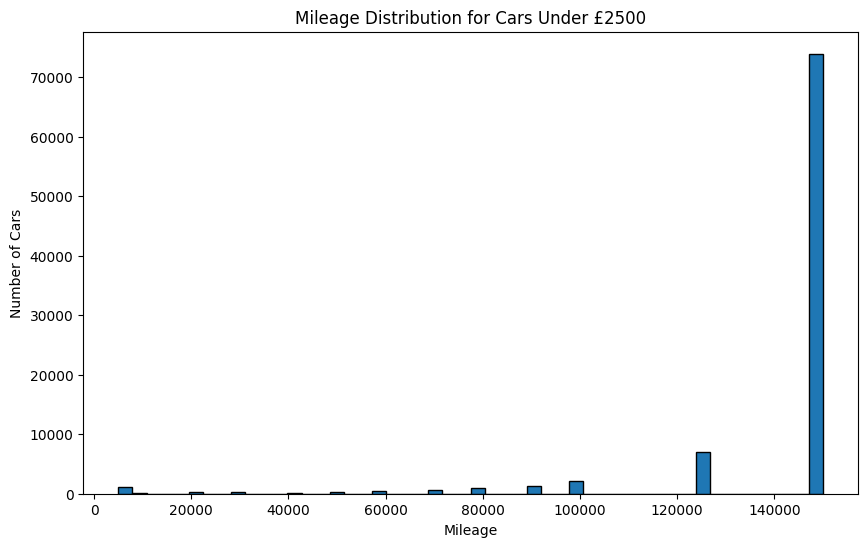

In [17]:
# Filter cars under £500
low_price_cars = df[df['Price'] <= 2500]

# Create mileage distribution
mileage_dist = low_price_cars['Mileage'].describe()
print("Mileage Statistics for Cars Under 2500:")
print(mileage_dist)

# Create a histogram for visual distribution

plt.figure(figsize=(10, 6))
plt.hist(low_price_cars['Mileage'], bins=50, edgecolor='black')
plt.title('Mileage Distribution for Cars Under £2500')
plt.xlabel('Mileage')
plt.ylabel('Number of Cars')
plt.show()

Total number of cars: 194921
Cars with exactly 150,000 miles: 137386
Percentage of cars with 150,000 miles: 70.48%


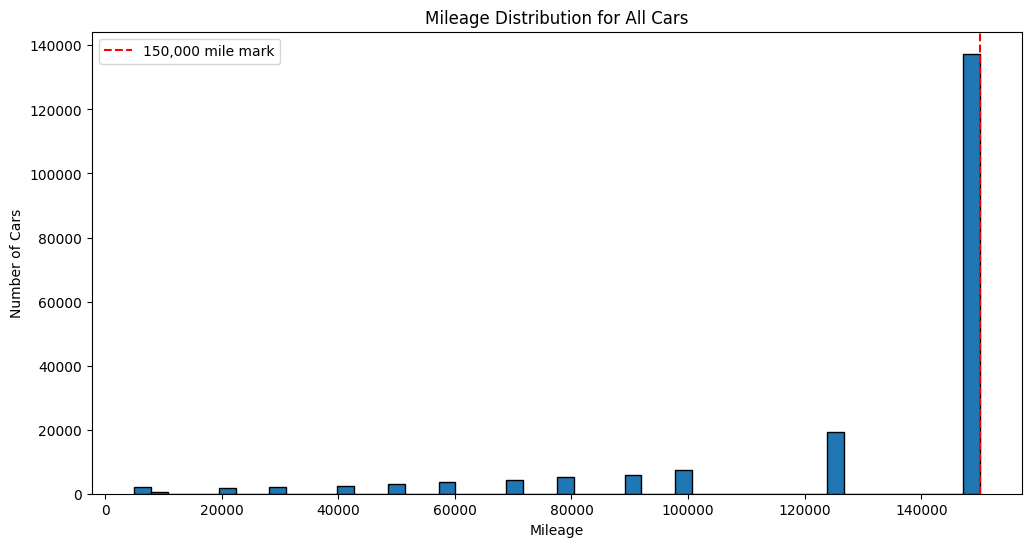

In [18]:
# value counts of mileage
mileage_counts = df['Mileage'].value_counts().sort_index()

# percentage of cars with 150,000 miles
total_cars = len(df)
cars_150k = len(df[df['Mileage'] == 150000])
percentage_150k = (cars_150k / total_cars) * 100

print(f"Total number of cars: {total_cars}")
print(f"Cars with exactly 150,000 miles: {cars_150k}")
print(f"Percentage of cars with 150,000 miles: {percentage_150k:.2f}%")

# visualize the distribution

plt.figure(figsize=(12, 6))
plt.hist(df['Mileage'], bins=50, edgecolor='black')
plt.title('Mileage Distribution for All Cars')
plt.xlabel('Mileage')
plt.ylabel('Number of Cars')
plt.axvline(x=150000, color='r', linestyle='--', label='150,000 mile mark')
plt.legend()
plt.show()

In [19]:
df500 = df[df['Price'] > 500]

Removed the cars that are under $500 as cars don't sell for that low unless they are a salvage and sold for parts. There are a lot of cars with the maximum amount of miles 150,000 accounting for 66% of our data. We removed the lower end of cars in an attempt to lower the initial RMSE.

In [20]:
print("summary of numerical features:")
print(df500.select_dtypes(include=['int64', 'float64']).describe())


summary of numerical features:
               Price  RegistrationYear          Power        Mileage  \
count  180508.000000     180508.000000  180508.000000  180508.000000   
mean     4971.539195       2002.264781     119.644597  130601.995479   
std      4469.918404          6.508388     177.614297   35200.359299   
min       501.000000       1910.000000       0.000000    5000.000000   
25%      1549.000000       1999.000000      75.000000  125000.000000   
50%      3333.000000       2003.000000     114.000000  150000.000000   
75%      6999.000000       2007.000000     150.000000  150000.000000   
max     20000.000000       2018.000000   19211.000000  150000.000000   

       RegistrationMonth  NumberOfPictures     PostalCode  
count      180508.000000          180508.0  180508.000000  
mean            6.118626               0.0   51441.734654  
std             3.546504               0.0   25671.000117  
min             0.000000               0.0    1067.000000  
25%             3.00

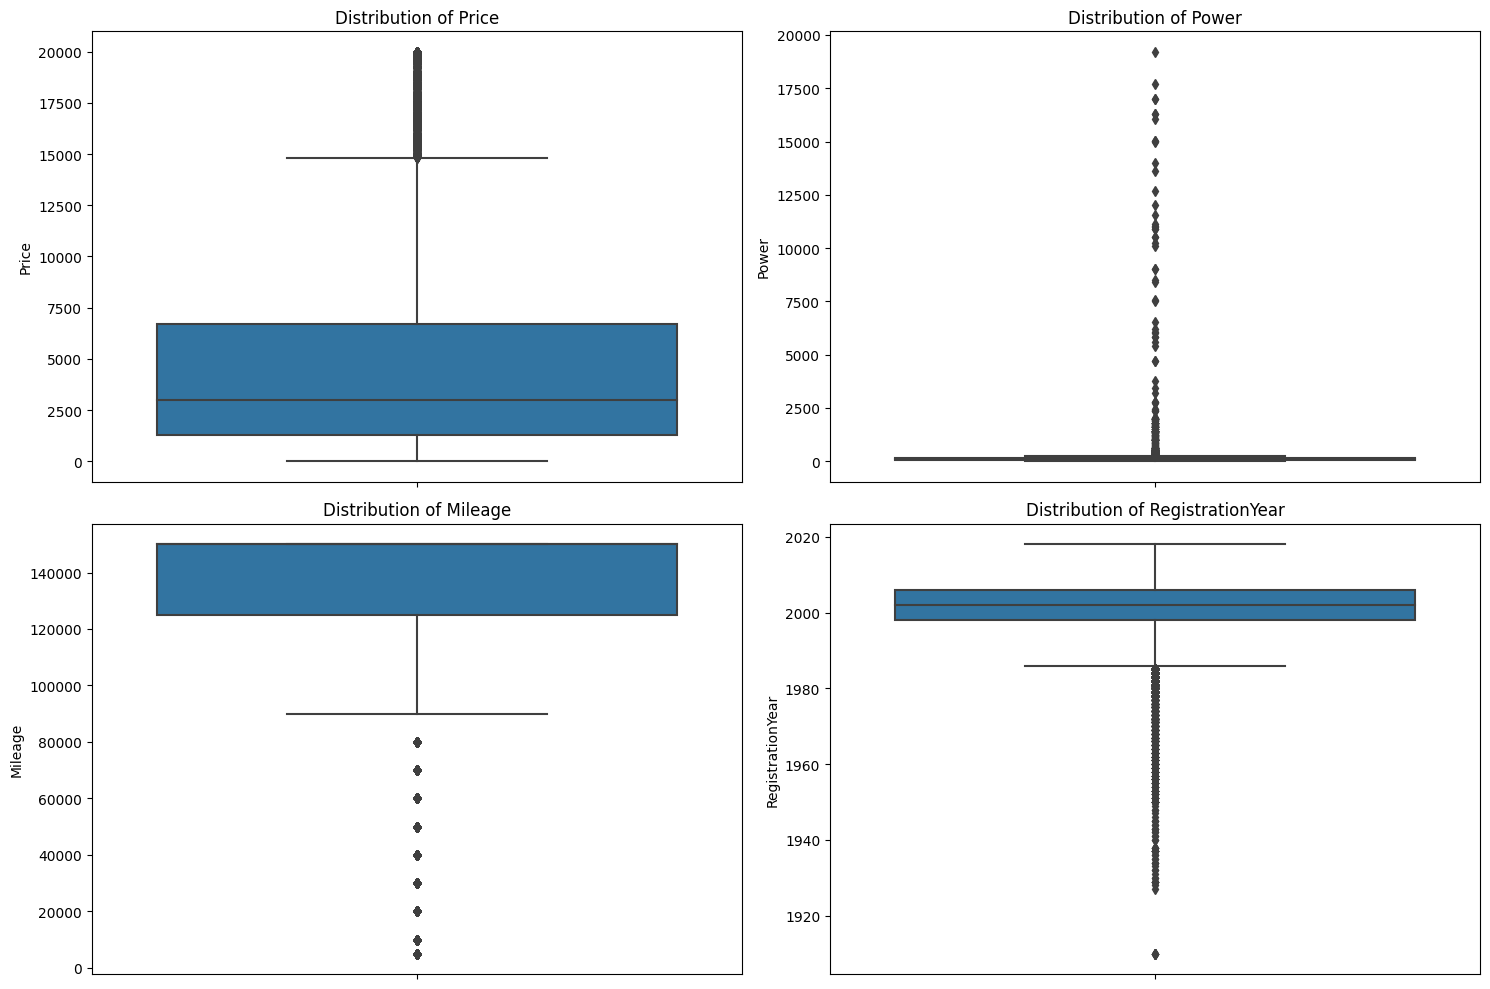

In [21]:
# create chart for usable features
plt.figure(figsize=(15, 10))

numerical_features = ['Price', 'Power', 'Mileage', 'RegistrationYear']
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[feature])
    plt.title(f'Distribution of {feature}')

plt.tight_layout()
plt.show()

In [22]:
# remove 0 hp and high hp cars > 1000
df500 = df500[(df500['Power'] > 0) & (df500['Power'] < 1000)]
# did it work
print(df500['Power'].describe())

count    169199.000000
mean        124.498460
std          52.684882
min           1.000000
25%          86.000000
50%         116.000000
75%         150.000000
max         999.000000
Name: Power, dtype: float64


In [23]:
# drop old cars registered before 1950
df500 = df500[df500['RegistrationYear'] >= 1950]
print(df500['RegistrationYear'].describe())

count    169164.000000
mean       2002.435548
std           6.299450
min        1950.000000
25%        1999.000000
50%        2003.000000
75%        2007.000000
max        2018.000000
Name: RegistrationYear, dtype: float64


## Model training

In [24]:
# publication period
df500['DateCreated'] = pd.to_datetime(df500['DateCreated'])
df500['DateCrawled'] = pd.to_datetime(df500['DateCrawled'])
df500['Publication'] = (df500['DateCrawled'] - df500['DateCreated']).dt.days
# get year from DateCrawled
df500['CrawledYear'] = df500['DateCrawled'].dt.year
# RegistrationYear is greater than CrawledYear
invalid_dates = df500[df500['RegistrationYear'] > df500['CrawledYear']]

print("Number of invalid registration years:", len(invalid_dates))

# drop CrawledYear column
df500 = df500.drop('CrawledYear', axis=1)
# drop unneeded xolumns
dropped = ['DateCrawled', 'DateCreated', 'LastSeen', 'RegistrationMonth', 'RegistrationYear', 'PostalCode', 
                          'NumberOfPictures', 'VehicleType', 'Brand']
df500 = df.drop(columns=dropped, axis=1)


Number of invalid registration years: 9


In [25]:
print(df500.duplicated().sum())
df500 = df500.drop_duplicates()
print(df500.duplicated().sum())

68587
0


In [26]:
# features and target
target = df500['Price']
features = df500.drop('Price', axis=1)

In [27]:
### Moved
# split data
X_temp, X_test_final, y_temp, y_test_final = train_test_split(
    features, target, test_size=0.2, random_state=12345  
)
#split temp into training
X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp,
    y_temp,
    test_size=0.2,   
    random_state=12345
)

In [28]:
print("Before encoding:")
print("X_train shape:", X_train.shape)
print("\nMissing values in X_train:")
print(X_train.isna().sum())
print("\nAvailable columns in X_train:")
print(X_train.columns.tolist())
numerical_features = ['Power', 'Mileage']
print("\nNumerical features:", numerical_features)
print("\nShape of numerical features in X_train:", X_train[numerical_features].shape)

Before encoding:
X_train shape: (80853, 6)

Missing values in X_train:
Gearbox        0
Power          0
Model          0
Mileage        0
FuelType       0
NotRepaired    0
dtype: int64

Available columns in X_train:
['Gearbox', 'Power', 'Model', 'Mileage', 'FuelType', 'NotRepaired']

Numerical features: ['Power', 'Mileage']

Shape of numerical features in X_train: (80853, 2)


In [29]:
# OneHotEncoder for categorical variables
categorical_features = ['Gearbox', 'Model', 'FuelType', 'NotRepaired']
encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)

# fit encoder on training data
X_train_encoded = pd.DataFrame(
    encoder.fit_transform(X_train[categorical_features]),
    index=X_train.index
)
X_valid_encoded = pd.DataFrame(
    encoder.transform(X_valid[categorical_features]),
    index=X_valid.index
)
X_test_encoded = pd.DataFrame(
    encoder.transform(X_test_final[categorical_features]),
    index=X_test_final.index
)

# feature names for encoder
feature_names = encoder.get_feature_names(categorical_features)
X_train_encoded.columns = feature_names
X_valid_encoded.columns = feature_names
X_test_encoded.columns = feature_names

# put non-categorical features back
numerical_features = [col for col in X_train.columns if col not in categorical_features]
X_train_final = pd.concat([X_train[numerical_features], X_train_encoded], axis=1)
X_valid_final = pd.concat([X_valid[numerical_features], X_valid_encoded], axis=1)
X_test_final = pd.concat([X_test_final[numerical_features], X_test_encoded], axis=1)

print('Training set:', X_train_final.shape)
print('Validation set:', X_valid_final.shape)
print('Test set:', X_test_final.shape)

Training set: (80853, 39)
Validation set: (20214, 39)
Test set: (25267, 39)


In [30]:
### moved up
# split data
#x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=12345)
# show the shapes
#print('x_train:', x_train.shape)
#print('x_test:', x_test.shape)
# time implementation
#start_time = time.time()

In [57]:
# linear regression model
lr_model = LinearRegression()

# measure fitting time
start_time = time.time()
lr_model.fit(X_train_final, y_train)
lr_train_time = time.time() - start_time


In [58]:
# Check for NaN values
print("NaN values in X_train_final:", X_train_final.isna().sum().sum())
print("Infinite values in X_train_final:", np.isinf(X_train_final).sum().sum())

# Check NaN values by column
print("NaN values per column:")
print(X_train_final.isna().sum())

NaN values in X_train_final: 0
Infinite values in X_train_final: 0
NaN values per column:
Power                  0
Mileage                0
Gearbox_auto           0
Gearbox_manual         0
Gearbox_unknown        0
Model_1er              0
Model_2_reihe          0
Model_3_reihe          0
Model_3er              0
Model_5er              0
Model_a3               0
Model_a4               0
Model_a6               0
Model_a_klasse         0
Model_astra            0
Model_c_klasse         0
Model_corsa            0
Model_e_klasse         0
Model_fiesta           0
Model_focus            0
Model_fortwo           0
Model_golf             0
Model_mondeo           0
Model_other            0
Model_passat           0
Model_polo             0
Model_touran           0
Model_transporter      0
Model_twingo           0
Model_vectra           0
FuelType_cng           0
FuelType_electric      0
FuelType_hybrid        0
FuelType_lpg           0
FuelType_other         0
FuelType_petrol        0
NotRepaire

In [59]:
# make predictions
start_time = time.time()
y_pred_train = lr_model.predict(X_train_final)
y_pred_valid = lr_model.predict(X_valid_final)
lr_predict_time = time.time() - start_time

lr_rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
lr_rmse_valid = np.sqrt(mean_squared_error(y_valid, y_pred_valid))
print("Train RMSE:", lr_rmse_train)
print("Valid RMSE:", lr_rmse_valid)
print(f"Training time:", lr_train_time, "seconds")
print(f"Prediction time:", lr_predict_time, "seconds")

Train RMSE: 3860.3045228806473
Valid RMSE: 3845.0230839353053
Training time: 0.06406426429748535 seconds
Prediction time: 0.009554386138916016 seconds


In [60]:
print("Average price in training set:", y_train.mean())
print("Percentage error:", (lr_rmse_train / y_train.mean()) * 100, "%")

Average price in training set: 5269.338057957033
Percentage error: 73.2597620502132 %


In [61]:
print("Size of original target:", len(target))
print("Size of y_temp:", len(y_temp))
print("Size of y_train:", len(y_train))
print("Size of y_valid:", len(y_valid))
print("Size of y_test_final:", len(y_test_final))

Size of original target: 126334
Size of y_temp: 101067
Size of y_train: 80853
Size of y_valid: 20214
Size of y_test_final: 25267


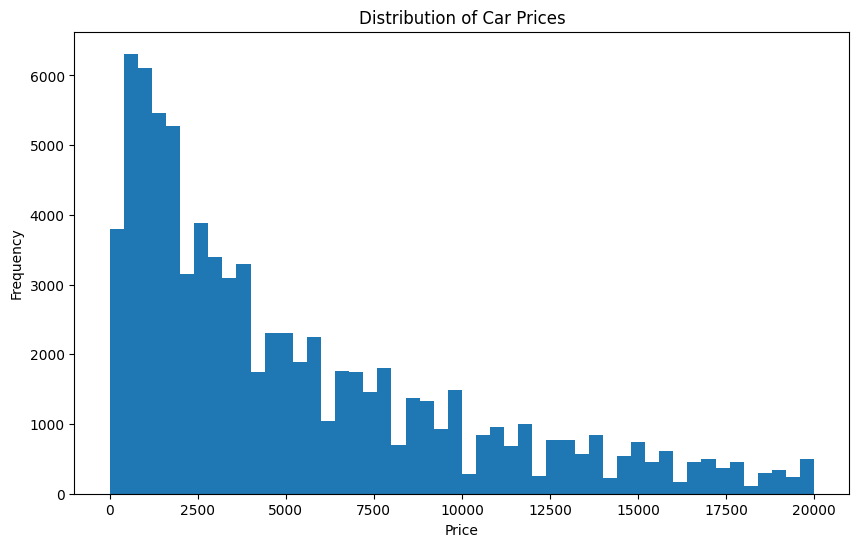

Price Statistics:
count   80853.000
mean     5269.338
std      4772.867
min         1.000
25%      1500.000
50%      3600.000
75%      7799.000
max     20000.000
Name: Price, dtype: float64


In [62]:
# price distribution
plt.figure(figsize=(10, 6))
plt.hist(y_train, bins=50)
plt.title('Distribution of Car Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

# target (price) stats
print("Price Statistics:")
print(y_train.describe())

In [63]:
# create df with actual and predicted values
results_df_lr = pd.DataFrame({
    'actual': y_train,
    'predicted': y_pred_train,
    'abs_error': np.abs(y_train - y_pred_train),
    'percentage_error': np.abs((y_train - y_pred_train) / y_train) * 100
})

# Create price brackets
bins = [500, 2000, 5000, 10000, 15000, 20000]
labels = ['500-2000', '2000-5000', '5000-10000', '10000-15000', '15000-20000']
results_df_lr['price_bracket'] = pd.cut(results_df_lr['actual'], bins=bins, labels=labels)

# Calculate metrics for each bracket
bracket_stats = results_df_lr.groupby('price_bracket').agg({
    'actual': 'count',
    'abs_error': 'mean',
    'percentage_error': 'mean'
}).round(2)

# change column names
bracket_stats.columns = ['Count', 'Mean Absolute Error', 'Mean Percentage Error']
print(bracket_stats)

               Count  Mean Absolute Error  Mean Percentage Error
price_bracket                                                   
500-2000       21681             2734.850                252.430
2000-5000      22624             2118.020                 67.930
5000-10000     18345             1968.380                 26.720
10000-15000     8390             4869.000                 38.300
15000-20000     4546             8693.020                 49.540


In [38]:
# decision tree model
dt_model = DecisionTreeRegressor(random_state=12345)

start_time = time.time()
dt_model.fit(X_train_final, y_train)
dt_train_time = time.time() - start_time

# predictions 
dt_pred_start_time = time.time()
dt_pred_train = dt_model.predict(X_train_final)
dt_pred_valid = dt_model.predict(X_valid_final)
dt_pred_time = time.time() - dt_pred_start_time

# RMSE
dt_rmse_train = np.sqrt(mean_squared_error(y_train, dt_pred_train))
dt_rmse_valid = np.sqrt(mean_squared_error(y_valid, dt_pred_valid))

print("Basic Decision Tree Results:")
print("Training RMSE:", round(dt_rmse_train, 2))
print("Valid RMSE:", round(dt_rmse_valid, 2))
print(f"Training time: {dt_train_time:.2f} seconds")
print(f"Prediction time: {dt_pred_time:.2f} seconds")

Basic Decision Tree Results:
Training RMSE: 2239.11
Valid RMSE: 3027.25
Training time: 0.00 seconds
Prediction time: 0.03 seconds


In [39]:
# Hyperparameter tuning
param_grid_dt = {
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# train model with GridSearchCV
dt_param_start_time = time.time()

dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=12345),
    param_grid_dt,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

dt_grid.fit(X_train_final, y_train)

dt_tuned_train_time = time.time() - dt_param_start_time

# predictions with best model
dt_tuned_pred_start_time = time.time()
dt_tuned_pred_train = dt_grid.predict(X_train_final)
dt_tuned_pred_valid = dt_grid.predict(X_valid_final)
dt_tuned_pred_time = time.time() - dt_tuned_pred_start_time

# RMSE for tuned model
dt_tuned_rmse_train = np.sqrt(mean_squared_error(y_train, dt_tuned_pred_train))
dt_tuned_rmse_valid = np.sqrt(mean_squared_error(y_valid, dt_tuned_pred_valid))

print("Tuned Decision Tree Results:")
print("Best parameters:", dt_grid.best_params_)
print("Training RMSE:", round(dt_tuned_rmse_train, 2))
print("Valid RMSE:", round(dt_tuned_rmse_valid, 2))
print(f"Training time: {dt_tuned_train_time:.2f} seconds")
print(f"Prediction time: {dt_tuned_pred_time:.2f} seconds")

Tuned Decision Tree Results:
Best parameters: {'max_depth': 15, 'min_samples_leaf': 4, 'min_samples_split': 10}
Training RMSE: 2733.9
Valid RMSE: 2966.6
Training time: 5.70 seconds
Prediction time: 0.02 seconds


The best parameters for the Decision Tree are max depth of 15, min leaf samples of 4 and minimum split of 10 samples. The Linear regression model returned a training RMSE of 3860.3045228806473
Valid 3845.0230839353053 and a Valid RMSE 3845.0230839353053. These results are higher than the Decision Tree training RMSE of 1464.04 and test RMSE of 1836.34 suggesting that the Decision Tree model performs better than Linear Regression.
The training time for Decision tree is 5.7 seconds which is slower than the Linear Regression of .04 seconds. Both Prediction times are similar at 0.06 for Linear Regression and 0.02 for the Decision tree.

In [40]:
# Random forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=12345)

rf_start_time = time.time()
rf_model.fit(X_train_final, y_train)
rf_train_time = time.time() - rf_start_time

# predictions
rf_pred_train = rf_model.predict(X_train_final)
rf_pred_valid = rf_model.predict(X_valid_final)
rf_predict_time = time.time() - rf_start_time

# RMSE
rf_train_rmse = np.sqrt(mean_squared_error(y_train, rf_pred_train))
rf_valid_rmse = np.sqrt(mean_squared_error(y_valid, rf_pred_valid))
print("Standard Random Forest")
print("Training RMSE:", round(rf_train_rmse, 2))
print("Valid RMSE:", round(rf_valid_rmse, 2))
print(f"Training time: {rf_train_time:.2f} seconds")
print(f"Prediction time: {rf_predict_time:.2f} seconds")

Standard Random Forest
Training RMSE: 2295.65
Valid RMSE: 2843.71
Training time: 13.04 seconds
Prediction time: 14.84 seconds


In [41]:
# Hyperparameters
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
# train with GridSearch
rf_tuned_start_time = time.time()
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=12345),
    param_grid_rf,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs = -1
)
rf_grid.fit(X_train_final, y_train)
rf_tuned_train_time = time.time() - rf_tuned_start_time

In [42]:
# predictions
rf_tuned_prediction_start_time = time.time()
rf_tuned_pred_train = rf_grid.predict(X_train_final)
rf_tuned_pred_valid = rf_grid.predict(X_valid_final)
rf_tuned_predict_time = time.time() - rf_tuned_prediction_start_time

# RMSE
rf_tuned_rmse_train = np.sqrt(mean_squared_error(y_train, rf_tuned_pred_train))
rf_tuned_rmse_valid = np.sqrt(mean_squared_error(y_valid, rf_tuned_pred_valid))

print("Tuned Random Forest Results:")
print("Best parameters:", rf_grid.best_params_)
print("Training RMSE:", round(rf_tuned_rmse_train, 2))
print("Valid RMSE:", round(rf_tuned_rmse_valid, 2))
print(f"Training time: {rf_tuned_train_time:.2f} seconds")
print(f"Prediction time: {rf_tuned_predict_time:.2f} seconds")

Tuned Random Forest Results:
Best parameters: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Training RMSE: 2582.48
Valid RMSE: 2843.21
Training time: 126.95 seconds
Prediction time: 1.00 seconds


In [43]:
# feature importance
feature_importance_rf = pd.DataFrame({
    'feature': X_train_final.columns,
    'importance': rf_grid.best_estimator_.feature_importances_
})
print("\nTop 10 Most Important Features:")
print(feature_importance_rf.sort_values('importance', ascending=False).head(10))


Top 10 Most Important Features:
              feature  importance
0               Power    0.501492
1             Mileage    0.291054
36     NotRepaired_no    0.043833
27  Model_transporter    0.024156
23        Model_other    0.011110
8           Model_3er    0.009458
21         Model_golf    0.009410
11           Model_a4    0.009174
2        Gearbox_auto    0.007786
5           Model_1er    0.007199


In [44]:
# Lightgbm model

train_data = lgb.Dataset(X_train_final, label=y_train)
valid_data = lgb.Dataset(X_valid_final, label=y_valid)

# hyperparameters
lgb_params_1 = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9
}

# train lgb model
train_start_time = time.time()
lgb_model = lgb.train(
    lgb_params_1,
    train_data,
    num_boost_round = 100,
    valid_sets = [train_data, valid_data],
    verbose_eval = 20
)
training_time_lgb = time.time() - train_start_time

[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002519 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 343
[LightGBM] [Info] Number of data points in the train set: 80853, number of used features: 39
[LightGBM] [Info] Start training from score 5269.338058


/.venv/lib/python3.9/site-packages/lightgbm/engine.py:239: UserWarning: 'verbose_eval' argument is deprecated and will be removed in a future release of LightGBM. Pass 'log_evaluation()' callback via 'callbacks' argument instead.
  _log_warning("'verbose_eval' argument is deprecated and will be removed in a future release of LightGBM. "


[20]	training's rmse: 3531.26	valid_1's rmse: 3515.65
[40]	training's rmse: 3194.85	valid_1's rmse: 3187.58
[60]	training's rmse: 3071.05	valid_1's rmse: 3069.8
[80]	training's rmse: 2997.43	valid_1's rmse: 3002.24
[100]	training's rmse: 2951.52	valid_1's rmse: 2961.78


In [45]:
# predictions
pred_start_time = time.time()
pred_lgb_train = lgb_model.predict(X_train_final)
pred_lgb_valid = lgb_model.predict(X_valid_final)
pred_time_lgb = time.time() - pred_start_time

# RMSE
rmse_lgb_train = np.sqrt(mean_squared_error(y_train, pred_lgb_train))
rmse_lgb_valid = np.sqrt(mean_squared_error(y_valid, pred_lgb_valid))

print("Lightgbm result")
print("Training RMSE:", round(rmse_lgb_train,2))
print("Valid RMSE:", round(rmse_lgb_valid, 2))
print("Training time:", training_time_lgb, "seconds")
print("Prediction time:", pred_time_lgb, "seconds")

Lightgbm result
Training RMSE: 2951.52
Valid RMSE: 2961.78
Training time: 1.2816405296325684 seconds
Prediction time: 0.3937394618988037 seconds


In [46]:
# hyperparameters
lgb_params = [   
    # conservative
    {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting': 'gbdt',
        'num_leaves': 31,
        'learning_rate': 0.1,
        'feature_fraction': 0.9,
        'bagging_fraction': 0.8,
        'bagging_freq': 5,
        'verbose': -1
    },
    # aggressive
    {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'num_leaves': 50,
        'learning_rate': 0.05,
        'feature_fraction': 0.8,
        'bagging_fraction': 0.7,
        'bagging_freq': 4,
        'verbose': -1
    },
    # preventing overfitting
    {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'num_leaves': 25,
        'learning_rate': 0.03,
        'feature_fraction': 0.85,
        'bagging_fraction': 0.9,
        'bagging_freq': 6,
        'min_data_in_leaf': 20,
        'verbose': -1
    }
]
# results
results = []

# evaluate different parameter sets
for i, params in enumerate(lgb_params, 1):
    print(f"\nTraining LightGBM with parameter set {i}")

    # train model
    train_start_time_lgb_hyp = time.time()
    lgb_hyp_model = lgb.train(
        params,
        train_data,
        num_boost_round = 100,
        valid_sets = [train_data, valid_data],
        verbose_eval = 20
    )
    train_time_lgb_hyp = time.time() - train_start_time_lgb_hyp

    # predictions
    pred_start_time_lgb_hyp = time.time()
    pred_train = lgb_hyp_model.predict(X_train_final)
    pred_valid = lgb_hyp_model.predict(X_valid_final)
    pred_time_lgb_hyp = time.time() - pred_start_time_lgb_hyp

    # RMSE
    rmse_train_lgb_hyp = np.sqrt(mean_squared_error(y_train, pred_train))
    rmse_valid_lgb_hyp = np.sqrt(mean_squared_error(y_valid, pred_valid))

    # import results
    results.append({
        'Parameter set': i,
        'RMSE train': rmse_train_lgb_hyp,
        'RMSE valid': rmse_valid_lgb_hyp,
        'Training time': train_time_lgb_hyp,
        'Predict time': pred_time_lgb_hyp
    })

    # find importance features
    feature_importance_lgb = pd.DataFrame({
        'feature': X_train_final.columns, 'importance': lgb_hyp_model.feature_importance()
    })
    print('Top Features')
    print(feature_importance_lgb.sort_values('importance', ascending=False))


Training LightGBM with parameter set 1


/.venv/lib/python3.9/site-packages/lightgbm/engine.py:239: UserWarning: 'verbose_eval' argument is deprecated and will be removed in a future release of LightGBM. Pass 'log_evaluation()' callback via 'callbacks' argument instead.
  _log_warning("'verbose_eval' argument is deprecated and will be removed in a future release of LightGBM. "


[20]	training's rmse: 3199.62	valid_1's rmse: 3189.9
[40]	training's rmse: 2997.53	valid_1's rmse: 3001.9
[60]	training's rmse: 2917.11	valid_1's rmse: 2931.93
[80]	training's rmse: 2868.38	valid_1's rmse: 2890.74
[100]	training's rmse: 2838.12	valid_1's rmse: 2868.22
Top Features
                feature  importance
0                 Power        1319
1               Mileage         444
36       NotRepaired_no          86
27    Model_transporter          84
8             Model_3er          81
23          Model_other          66
2          Gearbox_auto          54
5             Model_1er          52
11             Model_a4          51
29         Model_vectra          51
38      NotRepaired_yes          45
9             Model_5er          45
26         Model_touran          43
12             Model_a6          43
10             Model_a3          42
17       Model_e_klasse          41
3        Gearbox_manual          40
15       Model_c_klasse          40
21           Model_golf          3

/.venv/lib/python3.9/site-packages/lightgbm/engine.py:239: UserWarning: 'verbose_eval' argument is deprecated and will be removed in a future release of LightGBM. Pass 'log_evaluation()' callback via 'callbacks' argument instead.
  _log_warning("'verbose_eval' argument is deprecated and will be removed in a future release of LightGBM. "


[20]	training's rmse: 3493.35	valid_1's rmse: 3483.07
[40]	training's rmse: 3119.1	valid_1's rmse: 3119.1
[60]	training's rmse: 2988.78	valid_1's rmse: 2998.29
[80]	training's rmse: 2918.81	valid_1's rmse: 2936.34
[100]	training's rmse: 2876.95	valid_1's rmse: 2901.34
Top Features
                feature  importance
0                 Power        1738
1               Mileage         653
27    Model_transporter         174
8             Model_3er         167
36       NotRepaired_no         140
23          Model_other         125
11             Model_a4         124
29         Model_vectra         116
5             Model_1er         105
10             Model_a3         105
17       Model_e_klasse         100
38      NotRepaired_yes         100
21           Model_golf          92
15       Model_c_klasse          91
9             Model_5er          91
26         Model_touran          91
12             Model_a6          77
2          Gearbox_auto          76
14          Model_astra          7

/.venv/lib/python3.9/site-packages/lightgbm/engine.py:239: UserWarning: 'verbose_eval' argument is deprecated and will be removed in a future release of LightGBM. Pass 'log_evaluation()' callback via 'callbacks' argument instead.
  _log_warning("'verbose_eval' argument is deprecated and will be removed in a future release of LightGBM. "


[20]	training's rmse: 3870.51	valid_1's rmse: 3847.18
[40]	training's rmse: 3465.51	valid_1's rmse: 3450.36
[60]	training's rmse: 3271.72	valid_1's rmse: 3259.66
[80]	training's rmse: 3166.07	valid_1's rmse: 3156.24
[100]	training's rmse: 3101.71	valid_1's rmse: 3094.74
Top Features
                feature  importance
0                 Power         857
1               Mileage         452
27    Model_transporter         157
36       NotRepaired_no         131
38      NotRepaired_yes          87
5             Model_1er          81
29         Model_vectra          71
8             Model_3er          58
10             Model_a3          53
11             Model_a4          53
26         Model_touran          52
21           Model_golf          51
23          Model_other          40
33         FuelType_lpg          32
2          Gearbox_auto          29
25           Model_polo          23
6         Model_2_reihe          18
22         Model_mondeo          18
17       Model_e_klasse         

In [47]:
# comparison df
comparison_df_lgb = pd.DataFrame(results)
print("Model Comparison:")
print(comparison_df_lgb.round(2))

Model Comparison:
   Parameter set  RMSE train  RMSE valid  Training time  Predict time
0              1     2838.12     2868.22           1.28          0.31
1              2     2876.95     2901.34           1.80          0.49
2              3     3101.71     3094.74           1.21          0.39


conservative set ( set 1 ) performs the best out of the hyperparameters

In [48]:
# CatBoost
from catboost import CatBoostRegressor
# parameters
catboost_params = {
    'iterations': 100,
    'learning_rate': 0.1,
    'depth': 6,
    'loss_function': 'RMSE',
    'verbose': 20
}
#  train model
train_start_time = time.time()
catboost_model = CatBoostRegressor(**catboost_params)
catboost_model.fit(
    X_train_final, 
    y_train,
    eval_set=(X_valid_final, y_valid)
)
training_time_catboost = time.time() - train_start_time

0:	learn: 4568.7528958	test: 4533.5407526	best: 4533.5407526 (0)	total: 51.6ms	remaining: 5.11s
20:	learn: 3346.4323044	test: 3324.1982363	best: 3324.1982363 (20)	total: 133ms	remaining: 499ms
40:	learn: 3195.2984243	test: 3180.5319255	best: 3180.5319255 (40)	total: 212ms	remaining: 305ms
60:	learn: 3132.2136946	test: 3122.7696742	best: 3122.7696742 (60)	total: 290ms	remaining: 185ms
80:	learn: 3081.9513927	test: 3076.8393828	best: 3076.8393828 (80)	total: 369ms	remaining: 86.6ms
99:	learn: 3044.1592659	test: 3042.4022178	best: 3042.4022178 (99)	total: 443ms	remaining: 0us

bestTest = 3042.402218
bestIteration = 99



In [49]:
# predictions
pred_start_time = time.time()
pred_catboost_train = catboost_model.predict(X_train_final)
pred_catboost_valid = catboost_model.predict(X_valid_final)
pred_time_catboost = time.time() - pred_start_time

In [50]:
# RMSE
rmse_catboost_train = np.sqrt(mean_squared_error(y_train, pred_catboost_train))
rmse_catboost_valid = np.sqrt(mean_squared_error(y_valid, pred_catboost_valid))

# results
print("CatBoost Results:")
print("Training RMSE:", round(rmse_catboost_train, 2))
print("Valid RMSE:", round(rmse_catboost_valid, 2))
print("Training time:", round(training_time_catboost, 2), "seconds")
print("Prediction time:", round(pred_time_catboost, 2), "seconds")

CatBoost Results:
Training RMSE: 3044.16
Valid RMSE: 3042.4
Training time: 0.66 seconds
Prediction time: 0.01 seconds


In [51]:
# important features
feature_importance_cb = pd.DataFrame({
    'feature': X_train_final.columns,
    'importance': catboost_model.feature_importances_
})
print('Top Features:')
print(feature_importance_cb.sort_values('importance', ascending=False))

Top Features:
                feature  importance
0                 Power   47.139359
1               Mileage   28.977080
36       NotRepaired_no    6.411990
27    Model_transporter    3.520812
38      NotRepaired_yes    2.386787
5             Model_1er    1.373394
11             Model_a4    1.188456
29         Model_vectra    1.056951
21           Model_golf    1.053340
26         Model_touran    0.840330
10             Model_a3    0.829084
23          Model_other    0.746050
8             Model_3er    0.624845
2          Gearbox_auto    0.510571
33         FuelType_lpg    0.438101
25           Model_polo    0.354407
22         Model_mondeo    0.296093
9             Model_5er    0.281475
14          Model_astra    0.231578
3        Gearbox_manual    0.225842
24         Model_passat    0.224776
17       Model_e_klasse    0.224454
6         Model_2_reihe    0.219511
7         Model_3_reihe    0.185253
15       Model_c_klasse    0.183367
16          Model_corsa    0.127344
12            

In [52]:
# parameter sets
catboost_params_list = [
    # conservative
    {
        'iterations': 100,
        'learning_rate': 0.1,
        'depth': 6,
        'loss_function': 'RMSE',
        'verbose': 20
    },
    # aggressive
    {
        'iterations': 150,
        'learning_rate': 0.08,
        'depth': 8,
        'l2_leaf_reg': 3,
        'loss_function': 'RMSE',
        'verbose': 20
    },
    # no overfitting
    {
        'iterations': 100,
        'learning_rate': 0.05,
        'depth': 5,
        'l2_leaf_reg': 5,
        'min_data_in_leaf': 20,
        'loss_function': 'RMSE',
        'verbose': 20
    }
]

# results 
results = []

# different parameter sets
for i, params in enumerate(catboost_params_list, 1):
    print(f"\nTraining CatBoost with parameter set {i}")

    # train
    train_start_time = time.time()
    model = CatBoostRegressor(**params)
    model.fit(
        X_train_final, 
        y_train,
        eval_set=(X_valid_final, y_valid)
    )
    train_time = time.time() - train_start_time

    # predict
    pred_start_time = time.time()
    pred_train = model.predict(X_train_final)
    pred_valid = model.predict(X_valid_final)
    pred_time = time.time() - pred_start_time

    # RMSE
    rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
    rmse_valid = np.sqrt(mean_squared_error(y_valid, pred_valid))

    # update results
    results.append({
        'Parameter set': i,
        'RMSE train': rmse_train,
        'RMSE valid': rmse_valid,
        'Training time': train_time,
        'Predict time': pred_time
    })

    # important features
    feature_importance_cb_hyp = pd.DataFrame({
        'feature': X_train_final.columns,
        'importance': model.feature_importances_
    })
    print('Top Features:')
    print(feature_importance_cb_hyp.sort_values('importance', ascending=False))



Training CatBoost with parameter set 1
0:	learn: 4568.7528958	test: 4533.5407526	best: 4533.5407526 (0)	total: 8.72ms	remaining: 863ms
20:	learn: 3346.4323044	test: 3324.1982363	best: 3324.1982363 (20)	total: 98.7ms	remaining: 371ms
40:	learn: 3195.2984243	test: 3180.5319255	best: 3180.5319255 (40)	total: 178ms	remaining: 257ms
60:	learn: 3132.2136946	test: 3122.7696742	best: 3122.7696742 (60)	total: 257ms	remaining: 164ms
80:	learn: 3081.9513927	test: 3076.8393828	best: 3076.8393828 (80)	total: 337ms	remaining: 79ms
99:	learn: 3044.1592659	test: 3042.4022178	best: 3042.4022178 (99)	total: 418ms	remaining: 0us

bestTest = 3042.402218
bestIteration = 99

Top Features:
                feature  importance
0                 Power   47.139359
1               Mileage   28.977080
36       NotRepaired_no    6.411990
27    Model_transporter    3.520812
38      NotRepaired_yes    2.386787
5             Model_1er    1.373394
11             Model_a4    1.188456
29         Model_vectra    1.056951

In [53]:
# comparison df
results_df_cb_hyp = pd.DataFrame(results)
print("Model Comparison:")
print(results_df_cb_hyp)

Model Comparison:
   Parameter set   RMSE train   RMSE valid  Training time  Predict time
0              1  3044.159266  3042.402218       0.583382      0.013347
1              2  2941.257323  2955.133070       0.930698      0.014099
2              3  3206.969742  3189.183159       0.525240      0.009908


The second set (agressive) performs best in this model, but it is the slowest but only by a small margin.

In [64]:
#  all model results
model_results = {
    'Model': ['Linear Regression', 'Basic Decision Tree', 'Tuned Decision Tree', 
              'Standard Random Forest', 'Tuned Random Forest', 'LightGBM', 'CatBoost'],
    'Train RMSE': [lr_rmse_train, dt_rmse_train, dt_tuned_rmse_train,
                   rf_train_rmse, rf_tuned_rmse_train, rmse_lgb_train, rmse_catboost_train],
    'Valid RMSE': [lr_rmse_valid, dt_rmse_valid, dt_tuned_rmse_valid,
                   rf_valid_rmse, rf_tuned_rmse_valid, rmse_lgb_valid, rmse_catboost_valid],
    'Training Time (s)': [lr_train_time, dt_train_time, dt_tuned_train_time,
                         rf_train_time, rf_tuned_train_time, training_time_lgb, training_time_catboost],
    'Prediction Time (s)': [lr_predict_time, dt_pred_time, dt_tuned_pred_time,
                           rf_predict_time, rf_tuned_predict_time, pred_time_lgb, pred_time_catboost]
}

# Create DataFrame
comparison_df = pd.DataFrame(model_results)

# Format the display
pd.set_option('display.float_format', '{:.3f}'.format)

# Sort by Valid RMSE to show best performing models first
comparison_df = comparison_df.sort_values('Valid RMSE')

print("Model Comparison Table (Sorted by Valid RMSE):")
print(comparison_df.to_string(index=False))


Model Comparison Table (Sorted by Valid RMSE):
                 Model  Train RMSE  Valid RMSE  Training Time (s)  Prediction Time (s)
   Tuned Random Forest    2582.481    2843.208            126.951                1.001
Standard Random Forest    2295.650    2843.709             13.039               14.840
              LightGBM    2951.522    2961.782              1.282                0.394
   Tuned Decision Tree    2733.903    2966.605              5.703                0.021
   Basic Decision Tree    2239.111    3027.252              0.000                0.030
              CatBoost    3044.159    3042.402              0.662                0.012
     Linear Regression    3860.305    3845.023              0.064                0.010


Picking the LightGBM due to the model being competitive in both areas by having a good score and fast speed compared to the other models who are good at one or the other.

In [66]:
# Best Model LGB
# test predictions
pred_start_time = time.time()
pred_lgb_test = lgb_model.predict(X_test_final)
test_pred_time = time.time() - pred_start_time

# test RMSE
rmse_lgb_test = np.sqrt(mean_squared_error(y_test_final, pred_lgb_test))

print("LightGBM Test Results:")
print(f"Test RMSE: {round(rmse_lgb_test, 2)}")
print(f"Prediction time: {round(test_pred_time, 3)} seconds")

LightGBM Test Results:
Test RMSE: 2984.49
Prediction time: 0.026 seconds


## Model analysis

Best performance in RMSE is the Tuned Random Forest on the validation set 2843.208. The tuned decision tree 2966.605 and the Lightgbm 2961.782 had a similar RMSE not far off of the Tuned Random forest score 2843.208. The baseline Linear regression was the worst in RMSE 3845.023. The Lightgbm model was picked due to its good RMSE score and its fast time compared to the Tuned Random Forest best RMSE scoring model which was very slow in training and stil slower in the validation. 
LightGBM(2951.522 2961.782 1.282 0.394),Tune RanForest (2582.481 2843.208 126.951 1.001)

# Checklist

Type 'x' to check. Then press Shift+Enter.

- [x]  Jupyter Notebook is open
- [ ]  Code is error free
- [ ]  The cells with the code have been arranged in order of execution
- [ ]  The data has been downloaded and prepared
- [ ]  The models have been trained
- [ ]  The analysis of speed and quality of the models has been performed